In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split

# decision tree for multioutput regression
from sklearn.datasets import make_regression
from sklearn.tree import DecisionTreeRegressor

# KNN for multioutput regression
from sklearn.datasets import make_regression
from sklearn.neighbors import KNeighborsRegressor

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from scipy.io import arff


In [4]:
data = arff.loadarff('/content/drive/MyDrive/Hasan sir/new_analysis/kemerer.arff')
df = pd.DataFrame(data[0])
df.head()

,ID,Language,Hardware,Duration,KSLOC,AdjFP,RAWFP,EffortMM
0,1.0,1.0,1.0,17.0,253.6,1217.1,1010.0,287.00
1,2.0,1.0,2.0,7.0,40.5,507.3,457.0,82.50
2,3.0,1.0,3.0,15.0,450.0,2306.8,2284.0,1107.31
3,4.0,1.0,1.0,18.0,214.4,788.5,881.0,86.90
4,5.0,1.0,2.0,13.0,449.9,1337.6,1583.0,336.30


In [5]:
df.describe()

,ID,Language,Hardware,Duration,KSLOC,AdjFP,RAWFP,EffortMM
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,8.000000,1.200000,2.333333,14.266667,186.573333,999.140000,993.866667,219.247333
std,4.472136,0.560612,1.676163,7.544787,136.817420,589.592082,597.426130,263.055429
min,1.000000,1.000000,1.000000,5.000000,39.000000,99.900000,97.000000,23.200000
25%,4.500000,1.000000,1.000000,9.000000,55.100000,599.100000,581.000000,83.250000
50%,8.000000,1.000000,2.000000,14.000000,164.800000,993.000000,976.000000,130.300000
75%,11.500000,1.000000,3.500000,17.500000,253.900000,1342.550000,1464.500000,252.800000
max,15.000000,3.000000,6.000000,31.000000,450.000000,2306.800000,2284.000000,1107.310000


<Axes: title={'center': 'Pearson Correlation of Features'}>

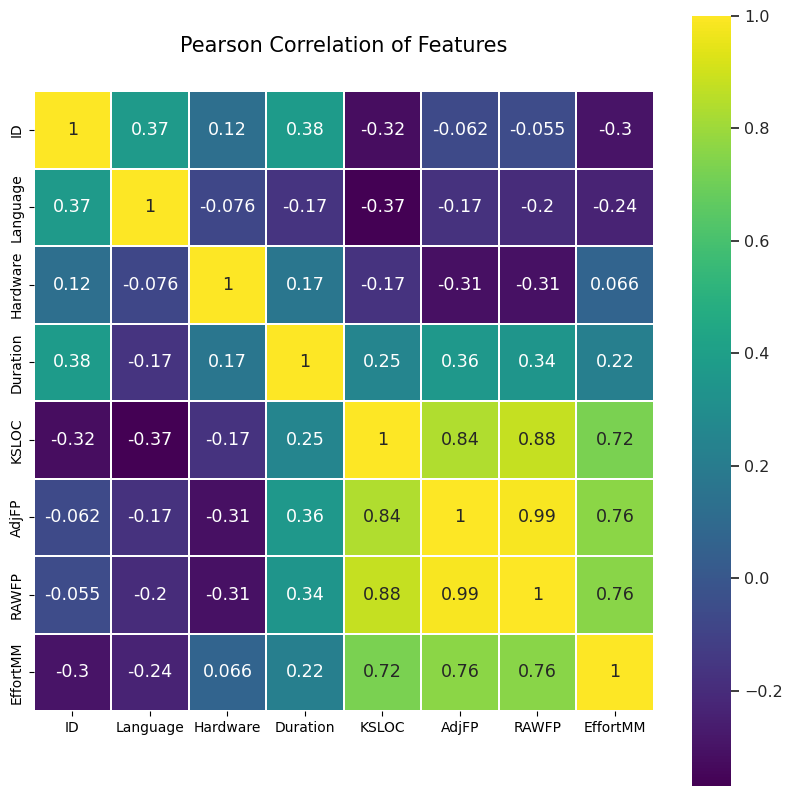

In [6]:
colormap = plt.cm.viridis
plt.figure(figsize=(10,10))
plt.title('Pearson Correlation of Features', y=1.05, size=15)
sns.set(font_scale=1.05)
sns.heatmap(df.astype(float).corr(),linewidths=0.1,vmax=1.0, square=True,cmap=colormap, linecolor='white', annot=True)

In [7]:
# map features to their absolute correlation values
corr = df.corr().abs()

# set equality (self correlation) as zero
corr[corr == 1] = 0

# of each feature, find the max correlation
# and sort the resulting array in ascending order
corr_cols = corr.max().sort_values(ascending=False)

# display the highly correlated fe
#corr_cols

# display the highly correlated features
display(corr_cols[corr_cols > 0.6])

AdjFP       0.987315
RAWFP       0.987315
KSLOC       0.878234
EffortMM    0.764544
dtype: float64

In [8]:
#features = [ 'TeamExp', 'ManagerExp', 'YearEnd', 'Length', 'Transactions', 'Entities','PointsNonAdjust', 'Adjustment', 'PointsAjust']

max_corr_features = ['AdjFP', 'RAWFP', 'KSLOC','EffortMM']

X = df[max_corr_features]
y = df['EffortMM']

In [9]:
# Splitting the dataset into the Training set and Test set
X_Train, X_Test, Y_Train, Y_Test = train_test_split(X, y, test_size=0.30, random_state=30)

# ***KNeighborsRegressor***

In [10]:
#KNeighborsRegressor
neigh = KNeighborsRegressor(n_neighbors=3, weights='uniform')
neigh.fit(X_Train, Y_Train)
predict_knn = neigh.predict(X_Test)
print("Root mean square: ", np.sqrt(mean_squared_error(Y_Test, predict_knn)))
print("Mean Absolute error", mean_absolute_error(Y_Test, predict_knn))

Root mean square:  93.01054539973171
Mean Absolute error 75.97999999999999


In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [12]:
# Function to calculate Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [13]:
# Calculate evaluation metrics
mae = mean_absolute_error(Y_Test, predict_knn)
mse = mean_squared_error(Y_Test, predict_knn)
rmse = np.sqrt(mse)
r_squared = r2_score(Y_Test, predict_knn)
mape = mean_absolute_percentage_error(Y_Test, predict_knn)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r_squared:.2f}")
print(f"mape: {mape:.2f}")

Mean Absolute Error (MAE): 75.98
Mean Squared Error (MSE): 8650.96
Root Mean Squared Error (RMSE): 93.01
R-squared (R²): -0.43
mape: 34.97


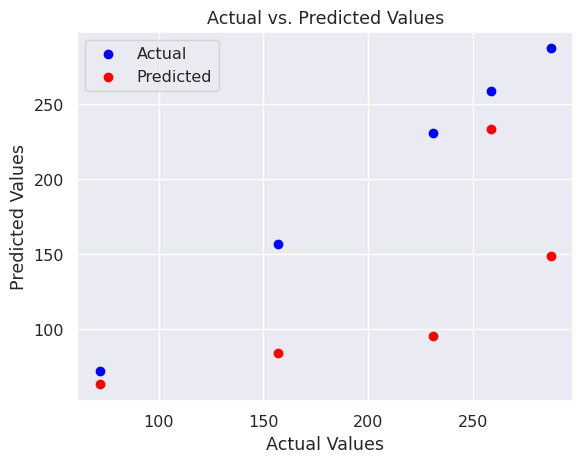

In [14]:
import matplotlib.pyplot as plt

# Sample actual and predicted values
actual_values = Y_Test                 #[0:50]
predicted_values = predict_knn             #[0:50]

# Create scatter plot for actual values
plt.scatter(actual_values, actual_values, c='blue', label='Actual')
# Create scatter plot for predicted values
plt.scatter(actual_values, predicted_values, c='red', label='Predicted')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.legend()
plt.grid(True)

plt.show()

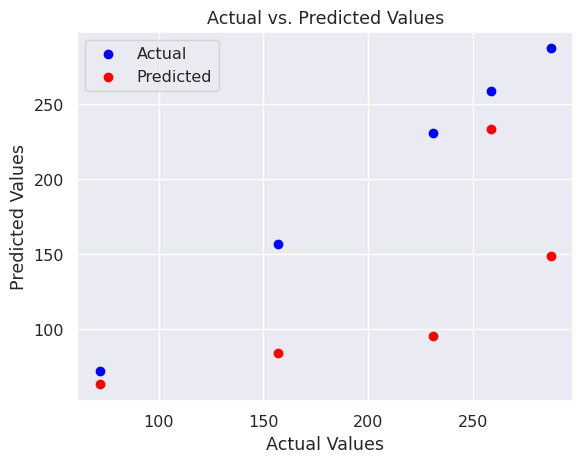

In [16]:
import matplotlib.pyplot as plt

# Sample actual and predicted values
actual_values = Y_Test                 #[0:50]
predicted_values = predict_knn             #[0:50]

# Create scatter plot for actual values
plt.scatter(actual_values, actual_values, c='blue', label='Actual')
# Create scatter plot for predicted values
plt.scatter(actual_values, predicted_values, c='red', label='Predicted')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.legend()
plt.grid(True)

plt.show()

# ***LinearRegression***

In [17]:
regressor = LinearRegression()
regressor.fit(X_Train, Y_Train)
predict_LR = regressor.predict(X_Test)
print("Root mean square: ", np.sqrt(mean_squared_error(Y_Test, predict_LR)))
print("Mean Absolute error", mean_absolute_error(Y_Test, predict_LR))

Root mean square:  1.1509915072631761e-13
Mean Absolute error 9.094947017729283e-14


In [18]:
# Function to calculate Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [19]:
# Calculate evaluation metrics
mae = mean_absolute_error(Y_Test, predict_LR)
mse = mean_squared_error(Y_Test, predict_LR)
rmse = np.sqrt(mse)
r_squared = r2_score(Y_Test, predict_LR)
mape = mean_absolute_percentage_error(Y_Test, predict_LR)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r_squared:.2f}")
print(f"mape: {mape:.2f}")

Mean Absolute Error (MAE): 0.00
Mean Squared Error (MSE): 0.00
Root Mean Squared Error (RMSE): 0.00
R-squared (R²): 1.00
mape: 0.00


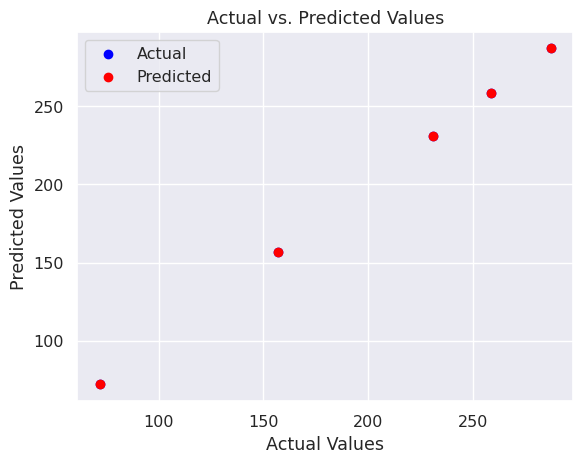

In [20]:
import matplotlib.pyplot as plt

# Sample actual and predicted values
actual_values = Y_Test                 #[0:50]
predicted_values = predict_LR             #[0:50]

# Create scatter plot for actual values
plt.scatter(actual_values, actual_values, c='blue', label='Actual')
# Create scatter plot for predicted values
plt.scatter(actual_values, predicted_values, c='red', label='Predicted')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.legend()
plt.grid(True)

plt.show()

# ***RandomForestRegressor***

In [21]:
regressor = RandomForestRegressor(n_estimators=100,max_features=5)
regressor.fit(X_Train, Y_Train)
predict_RF = regressor.predict(X_Test)
print("Root mean square: ", np.sqrt(mean_squared_error(Y_Test, predict_RF)))
print("Mean Absolute error", mean_absolute_error(Y_Test, predict_RF))

Root mean square:  49.80862065747264
Mean Absolute error 44.624600000000086


In [22]:
# Function to calculate Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [23]:
# Calculate evaluation metrics
mae = mean_absolute_error(Y_Test, predict_RF)
mse = mean_squared_error(Y_Test, predict_RF)
rmse = np.sqrt(mse)
r_squared = r2_score(Y_Test, predict_RF)
mape = mean_absolute_percentage_error(Y_Test, predict_RF)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r_squared:.2f}")
print(f"mape: {mape:.2f}")

Mean Absolute Error (MAE): 44.62
Mean Squared Error (MSE): 2480.90
Root Mean Squared Error (RMSE): 49.81
R-squared (R²): 0.59
mape: 24.74


In [24]:
# Function to calculate Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [25]:
# Calculate evaluation metrics
mae = mean_absolute_error(Y_Test, predict_RF)
mse = mean_squared_error(Y_Test, predict_RF)
rmse = np.sqrt(mse)
r_squared = r2_score(Y_Test, predict_RF)
mape = mean_absolute_percentage_error(Y_Test, predict_RF)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r_squared:.2f}")

Mean Absolute Error (MAE): 44.62
Mean Squared Error (MSE): 2480.90
Root Mean Squared Error (RMSE): 49.81
R-squared (R²): 0.59


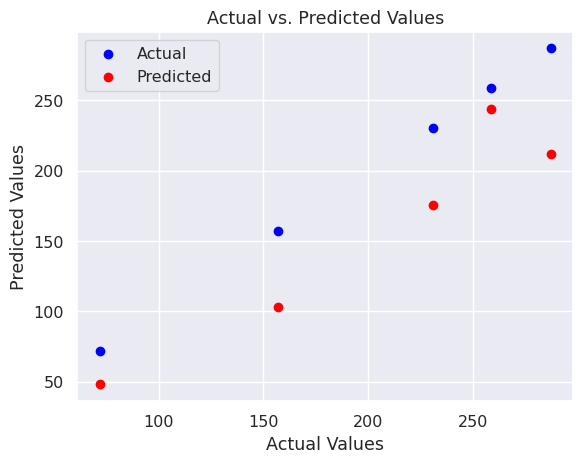

In [26]:
import matplotlib.pyplot as plt

# Sample actual and predicted values
actual_values = Y_Test                 #[0:50]
predicted_values = predict_RF             #[0:50]

# Create scatter plot for actual values
plt.scatter(actual_values, actual_values, c='blue', label='Actual')
# Create scatter plot for predicted values
plt.scatter(actual_values, predicted_values, c='red', label='Predicted')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.legend()
plt.grid(True)

plt.show()

# ***SVM***

In [27]:
parameters = {'kernel':('linear', 'rbf'), 'C':[1,2,3,4,5,6,7,8,9,10, 100, 500], 'gamma':('auto', 'scale')}

svr = SVR()
LinearSVC = GridSearchCV(svr, parameters, cv=3)
LinearSVC.fit(X_Train, Y_Train)
predict_SVM = LinearSVC.predict(X_Test)
print("Root mean square: ", np.sqrt(mean_squared_error(Y_Test, predict_SVM)))
print("Mean Absolute error", mean_absolute_error(Y_Test, predict_SVM))

Root mean square:  0.06591165759768512
Mean Absolute error 0.054919170888263126


In [28]:
# Function to calculate Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [29]:
# Calculate evaluation metrics
mae = mean_absolute_error(Y_Test, predict_SVM)
mse = mean_squared_error(Y_Test, predict_SVM)
rmse = np.sqrt(mse)
r_squared = r2_score(Y_Test, predict_SVM)
mape = mean_absolute_percentage_error(Y_Test, predict_SVM)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r_squared:.2f}")
print(f"mape: {mape:.2f}")

Mean Absolute Error (MAE): 0.05
Mean Squared Error (MSE): 0.00
Root Mean Squared Error (RMSE): 0.07
R-squared (R²): 1.00
mape: 0.05


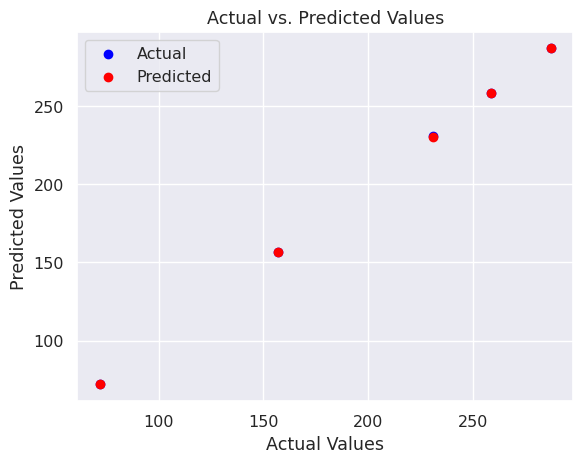

In [30]:
import matplotlib.pyplot as plt

# Sample actual and predicted values
actual_values = Y_Test                 #[0:50]
predicted_values = predict_SVM             #[0:50]

# Create scatter plot for actual values
plt.scatter(actual_values, actual_values, c='blue', label='Actual')
# Create scatter plot for predicted values
plt.scatter(actual_values, predicted_values, c='red', label='Predicted')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.legend()
plt.grid(True)

plt.show()

# ***lasso***

In [31]:
from sklearn import linear_model

In [32]:
clf = linear_model.Lasso(alpha=0.1)
clf.fit(X_Train, Y_Train)
print(clf.coef_)
print(clf.intercept_)
# make a prediction
predict_LS = clf.predict(X_Test)
# summarize prediction
print("Root mean square: ", np.sqrt(mean_squared_error(Y_Test, predict_LS)))
print("Mean Absolute error", mean_absolute_error(Y_Test, predict_LS))

[ 0.01670953 -0.01895395  0.01631671  0.99812278]
-0.09411187761133988
Root mean square:  2.16516084945784
Mean Absolute error 1.3165434999373757


In [33]:
# Function to calculate Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [34]:
# Calculate evaluation metrics
mae = mean_absolute_error(Y_Test, predict_LS)
mse = mean_squared_error(Y_Test, predict_LS)
rmse = np.sqrt(mse)
r_squared = r2_score(Y_Test, predict_LS)
mape = mean_absolute_percentage_error(Y_Test, predict_LS)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r_squared:.2f}")
print(f"mape: {mape:.2f}")

Mean Absolute Error (MAE): 1.32
Mean Squared Error (MSE): 4.69
Root Mean Squared Error (RMSE): 2.17
R-squared (R²): 1.00
mape: 0.57


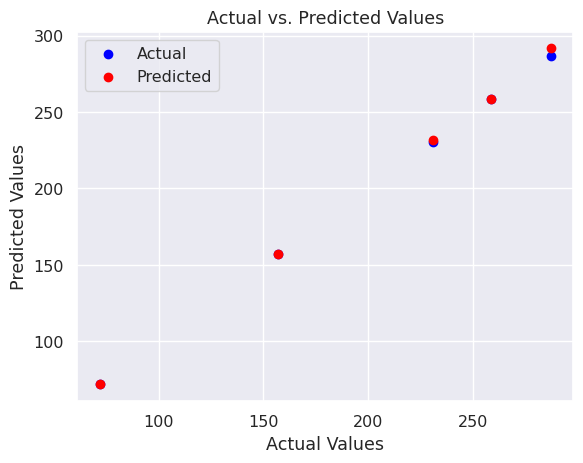

In [35]:
import matplotlib.pyplot as plt

# Sample actual and predicted values
actual_values = Y_Test                 #[0:50]
predicted_values = predict_LS             #[0:50]

# Create scatter plot for actual values
plt.scatter(actual_values, actual_values, c='blue', label='Actual')
# Create scatter plot for predicted values
plt.scatter(actual_values, predicted_values, c='red', label='Predicted')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.legend()
plt.grid(True)

plt.show()